# 0.0. Helper Functions

## 0.1. Imports

In [130]:
# ==========================================
# 1.0. IMPORTS
# ==========================================

# Standard Libraries
import random
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation & Analysis
import pandas as pd
import numpy as np
from IPython.core.display import HTML

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# Machine Learning - Preprocessing & Encoding
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing   import MinMaxScaler, RobustScaler, StandardScaler
from category_encoders       import CountEncoder, TargetEncoder

# Machine Learning - Models
import xgboost as xgb
from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import GradientBoostingClassifier

# Machine Learning - Metrics
from sklearn import metrics as mt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             cohen_kappa_score)

## 0.2. Functions

In [131]:
def jupyter_settings():
    """ Optimize general settings, standardize plot sizes, etc. """
    %matplotlib inline
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [12, 6]
    plt.rcParams['font.size'] = 12
    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    sns.set()
    pd.set_option('display.max_columns', 30)
    pd.set_option('display.max_rows', 30)
jupyter_settings()

def subplots_adjust():
    plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)
    return None

In [132]:
def model_metrics(X_test, y_test, yhat_proba, y_predict):
    """
    Calcula as métricas do modelo testado
    
    Args:
        X_test (pd.DataFrame) = Dataframe usado para teste do modelo (sem a coluna target)
        y_test (pd.Series) = Vetor de resposta real equivalente ao X_test
        
        yhat_proba (np.ndarray) = Probabilidade prevista pela pelo modelo para aquele conjunto de dados
        y_predict (pd.Series) = Classe prevista pela pelo modelo para aquele conjunto de dados
    """
    
    accuracy_score  = mt.accuracy_score(y_test, y_predict)
    precision_score = mt.precision_score(y_test, y_predict, labels=[1], zero_division=1)
    recall_score    = mt.recall_score(y_test, y_predict)
    f1_score        = mt.f1_score(y_test, y_predict)

    return accuracy_score,precision_score,recall_score,f1_score

In [133]:
# Implementando função mais otimizada
def calculate_data_recall_at_k(y_true, y_probas, k=0.4):
    """
    Calcula o Recall at K e gera os dados para curva de ganho cumulativo.
    """
    def get_cumulative_gain(y_actual, y_score):
        # Criando df
        df = pd.DataFrame({'response': y_actual, 'prob': y_score})
        df = df.sort_values('prob', ascending=False).reset_index(drop=True)
        
        df['recall_at_k'] = df['response'].cumsum() / df['response'].sum()
        df['base_at_k'] = (df.index + 1) / len(df)
        return df

    # Processamento para ambas as classes
    # y_probas[:, 1] -> Classe 1 | 1 - y_true -> Inverte labels para Classe 0
    df_class_1 = get_cumulative_gain(y_true, y_probas[:, 1])
    df_class_0 = get_cumulative_gain(1 - y_true, y_probas[:, 0])

    # Recall no ponto K desejado
    idx = np.searchsorted(df_class_1['base_at_k'], k)
    recall_at_k = df_class_1.iloc[idx]['recall_at_k']

    return df_class_0, df_class_1, recall_at_k

In [134]:
# Implementando função mais otimizada
def lineplot_recall_at_k(df_0, df_1, recall_at_k, k=0.4):
    """
    Plota a Curva de Ganho Cumulativo com anotação no ponto K.
    """
    # Configuração
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # Plotando as linhas principais
    plt.plot(df_1['base_at_k'], df_1['recall_at_k'], color='darkorange', lw=2, label='Classe 1')
    plt.plot(df_0['base_at_k'], df_0['recall_at_k'], color='royalblue', lw=2, label='Classe 0')
    
    # Baseline (Modelo Aleatório)
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Baseline (Random)')

    # Destaque do ponto K (Recall@K)
    plt.scatter(k, recall_at_k, color='red', s=50, zorder=5)
    plt.axvline(x=k, color='gray', linestyle='--', alpha=0.6)
    plt.axhline(y=recall_at_k, color='gray', linestyle='--', alpha=0.6)

    # Anotação
    plt.annotate(f'Recall@{k:.0%}: {recall_at_k:.2%}', 
                 xy=(k, recall_at_k), 
                 xytext=(k + 0.05, recall_at_k - 0.1),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                 arrowprops=dict(arrowstyle='->', color='black', connectionstyle="arc3,rad=.2"))

    # Formatação final
    plt.title('Cumulative Gains Curve', fontsize=15, pad=15)
    plt.xlabel('Percentual da Base (Sorted by Probability)', fontsize=12)
    plt.ylabel('Recall (Cumulative)', fontsize=12)
    plt.xlim([0, 1.02])
    plt.ylim([0, 1.02])
    plt.legend(loc='lower right', frameon=True)
    plt.grid(True, alpha=0.3) # Adiciona uma grade leve ao fundo
    
    plt.show()

In [135]:
def calculate_lift_data(y_test, yhat_proba):
    """
    Gera o DataFrame com os cálculos acumulados para a Curva Lift.

    Args:
        y_test (pd.Series)      = classe predita
        yhat_proba (np.ndarray) = probabilidade predita para classe
    """
    df = pd.DataFrame({'y_test': y_test, 'prob': yhat_proba[:, 1]})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)
    
    df['ranking'] = df.index + 1
    df['perc_base'] = df['ranking'] / len(df)
    
    # Acumulado de respostas positivas
    df['cum_response'] = df['y_test'].cumsum()
    df['propensity_score'] = df['cum_response'] / df['y_test'].sum()
    
    # Cálculo do Lift: Razão entre o modelo e o aleatório
    df['lift'] = df['propensity_score'] / df['perc_base']
    
    return df

In [136]:
def plot_lift_curve(lift_data, k=0.4):
    """
    Plota a Curva Lift a partir dos dados processados.

    Args:
        lift_data (pd.DataFrame) = Cálculos acumulados para a Curva Lift
    """
    # Coleta ponto de anotação (ex: Top 40%)
    lift_at_k = lift_data.loc[lift_data['perc_base'] >= k, 'lift'].iloc[0]
    x_val = lift_data.loc[lift_data['perc_base'] >= k, 'perc_base'].iloc[0]

    # Plot
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='perc_base', y='lift', data=lift_data, color='royalblue', label='Modelo')
    plt.axhline(y=1, color='black', linestyle='--', label='Baseline (Random)')
    
    # Estética e Anotações
    plt.scatter(x_val, lift_at_k, color='black', s=50, zorder=5)
    plt.annotate(f'Lift em {k*100}%: {lift_at_k:.2f}x', 
                 xy=(x_val, lift_at_k), 
                 xytext=(x_val + 0.05, lift_at_k + 0.5),
                 arrowprops=dict(color='black', arrowstyle='->', lw=1.5))

    plt.title('Lift Curve', fontsize=16)
    plt.xlabel('Percentual da Base (Sorted by Probability)')
    plt.ylabel('Lift')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return lift_at_k

# 1.0 Loading Data

In [137]:
df_raw = pd.read_csv('./dataset/df_raw.csv')

# 2.0 Data Description

In [138]:
df2 = df_raw.copy()

## 2.1 Rename Columns 

In [139]:
df2 = df2.rename(columns = {'vintage':'days_associated'})

## 2.2 Data Dimensions 

In [140]:
print(f'Linhas: {df2.shape[0]}')
print(f'Colunas: {df2.shape[1]}')

Linhas: 381109
Colunas: 12


## 2.3 Data Types

In [141]:
df2.dtypes

id                        int64
gender                   object
age                       int64
region_code             float64
policy_sales_channel    float64
driving_license           int64
vehicle_age              object
vehicle_damage           object
previously_insured        int64
annual_premium          float64
days_associated           int64
response                  int64
dtype: object

## 2.4 Check NA

In [142]:
df2.isna().sum()

id                      0
gender                  0
age                     0
region_code             0
policy_sales_channel    0
driving_license         0
vehicle_age             0
vehicle_damage          0
previously_insured      0
annual_premium          0
days_associated         0
response                0
dtype: int64

## 2.5 Fillout NA

In [143]:
# Não há nulos no dataset

## 2.6 Change types

In [144]:
# to object
df2['id'] = df2['id'].astype('object')

# to int
df2[['policy_sales_channel','region_code']] = df2[['policy_sales_channel','region_code']].astype('int64')

## 2.7 Descriptive Statistical

In [145]:
num_attributes = df2.select_dtypes( include= ['int64','float64'] )
cat_attributes = df2.select_dtypes( exclude= ['int64','float64', 'datetime64[ns]'] )

# Central Tendency - Mean, Median

ct1 = pd.DataFrame( num_attributes.apply(np.mean) ).T
ct2 = pd.DataFrame( num_attributes.apply(np.median) ).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
d2 = pd.DataFrame( num_attributes.apply( min ) ).T
d3 = pd.DataFrame( num_attributes.apply( max ) ).T
d4 = pd.DataFrame( num_attributes.apply(lambda x: x.max() - x.min()  ) ).T
d5 = pd.DataFrame( num_attributes.apply(lambda x: x.skew()  ) ).T
d6 = pd.DataFrame( num_attributes.apply(lambda x: x.kurtosis()  ) ).T

# concatenate

m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes','min','max','range','mean','median','std','skew','kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,age,20.0,85.0,65.0,38.822584,36.0,15.511591,0.672539,-0.565655
1,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-0.115266,-0.867857
2,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-0.900008,-0.970810
3,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-21.595182,464.354302
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,0.167747,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087,34.004569
6,days_associated,10.0,299.0,289.0,154.347397,154.0,83.671194,0.003030,-1.200688
7,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906,3.298788


# 3.0 Feature Engineering

In [146]:
df3 = df2.copy()

In [147]:
df3.sample(15)

,id,gender,age,region_code,policy_sales_channel,driving_license,vehicle_age,vehicle_damage,previously_insured,annual_premium,days_associated,response
218291,218292,Female,23,41,152,1,< 1 Year,No,1,35093.0,285,0
137101,137102,Female,72,8,30,1,1-2 Year,Yes,0,2630.0,165,0
246344,246345,Male,25,37,152,1,< 1 Year,Yes,0,29742.0,104,0
7760,7761,Female,23,28,124,1,< 1 Year,Yes,0,40104.0,146,0
119657,119658,Female,27,41,152,1,< 1 Year,No,1,36970.0,44,0
329923,329924,Female,59,3,124,1,1-2 Year,Yes,0,2630.0,91,0
201207,201208,Female,51,25,26,1,1-2 Year,Yes,0,44611.0,27,1
374532,374533,Male,50,28,124,1,1-2 Year,Yes,0,38505.0,120,0
289612,289613,Female,53,36,152,1,1-2 Year,No,1,33202.0,266,0
75245,75246,Male,51,41,26,1,1-2 Year,No,1,29231.0,102,0


## 3.1 Feature Engineering


In [148]:
# changing the categories in 'vehicle_age' column
vehicle_age_dict = {'< 1 Year':'below_1_year', '1-2 Year':'between_1_2_years', '> 2 Years':'more_than_2_years'}
df3['vehicle_age'] = df3['vehicle_age'].map(vehicle_age_dict)

# 4.0 Filtragem de variáveis

In [149]:
df4 = df3.copy()

# 5.0 EDA - Exploratory Data Analysis

In [150]:
df5 = df4.copy()

## 5.1 Análise Univariada

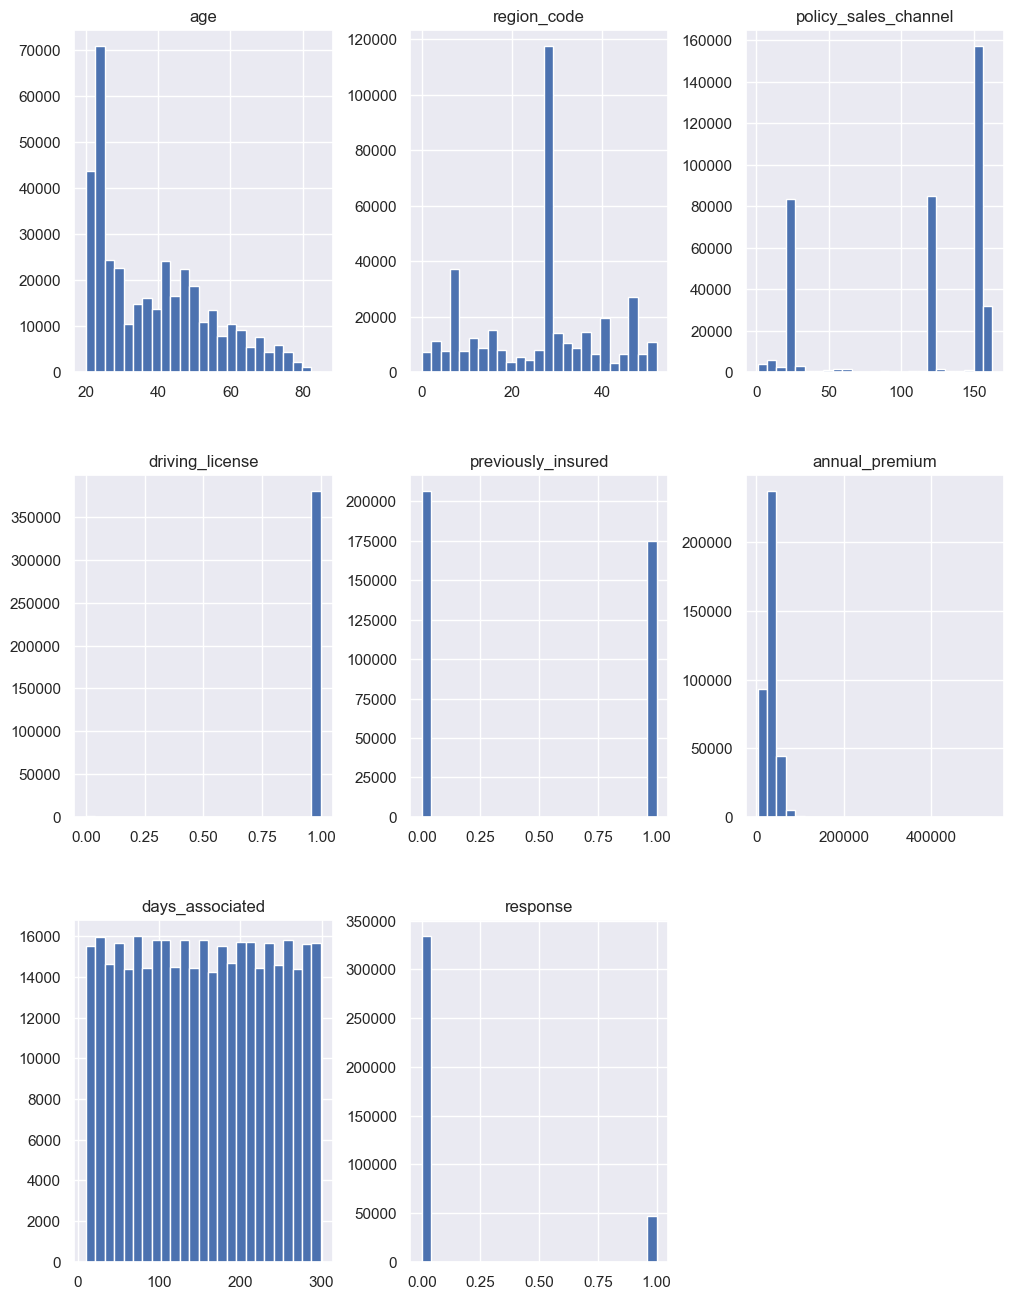

In [151]:
num_attributes.hist(bins=25, figsize=(12,16))
plt.show();

## 5.2 Análise Bivariada

In [152]:
table = [["H","Hipótese","Resposta"],
         ["H1","Mulheres sao mais propensas a adquirir o seguro saude","Falso" ],
         ["H2","Pessoas mais velhas sao mais propensas a adquirir o seguro saude","Falso" ],
         ["H3","Pessoas com carros mais velhos sao mais propensas a adquirir o seguro saude","Verdadeiro" ],
         ["H4","Pessoas com carros danificados sao mais propensas a adquirir o seguro saude","Verdadeiro" ],
         ["H5","Pessoas previamente asseguradas sao mais propensas a adquirir o seguro saude","Falso" ],
         ["H6","Pessoas que ganham mais sao mais propensas a adquirir o seguro saude","Falso" ],
         ["H7","H7 Pessoas a mais tempo associadas sao mais propensas a adquirir o seguro saude","Falso" ],
        ]
print(tabulate(table, tablefmt="github", headers="firstrow" , colalign=("center","center","center")))

|  H  |                                    Hipótese                                     |  Resposta  |
|-----|---------------------------------------------------------------------------------|------------|
| H1  |              Mulheres sao mais propensas a adquirir o seguro saude              |   Falso    |
| H2  |        Pessoas mais velhas sao mais propensas a adquirir o seguro saude         |   Falso    |
| H3  |   Pessoas com carros mais velhos sao mais propensas a adquirir o seguro saude   | Verdadeiro |
| H4  |   Pessoas com carros danificados sao mais propensas a adquirir o seguro saude   | Verdadeiro |
| H5  |  Pessoas previamente asseguradas sao mais propensas a adquirir o seguro saude   |   Falso    |
| H6  |      Pessoas que ganham mais sao mais propensas a adquirir o seguro saude       |   Falso    |
| H7  | H7 Pessoas a mais tempo associadas sao mais propensas a adquirir o seguro saude |   Falso    |


### 5.1 - H1 - Mulheres sao mais propensas a adquirir o seguro saude

Falso. Homens são mais propensos que mulheres

In [153]:
aux = df5.loc[:, ['gender','response']].groupby(by=['gender']).agg({'gender':'count','response':'sum'})
aux.columns = ['total','positive']
aux = aux.reset_index()
aux['percentual'] = aux['positive']/aux['total']
aux

,gender,total,positive,percentual
0,Female,175020,18185,0.103902
1,Male,206089,28525,0.138411


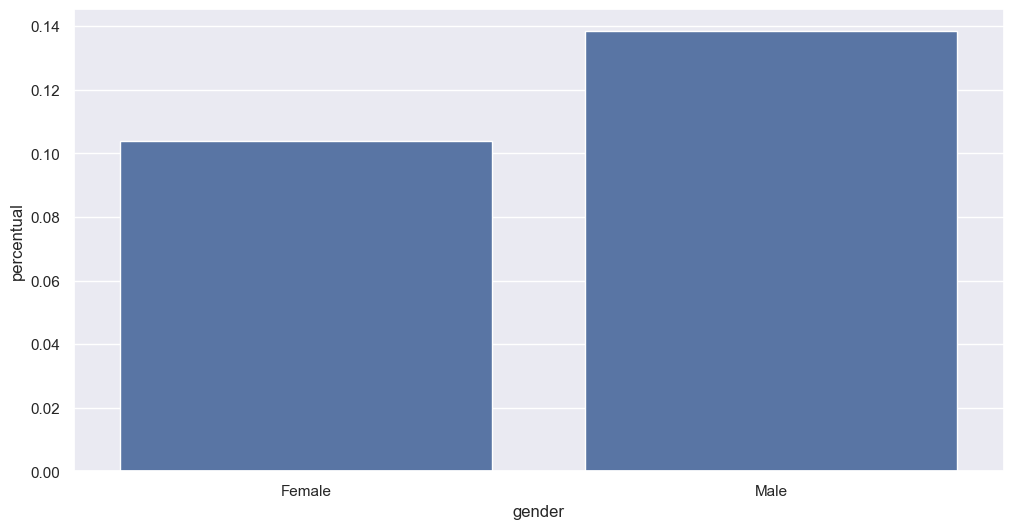

In [154]:
sns.barplot( x='gender',y='percentual', data = aux)
plt.show();

### 5.2 - H2 - Pessoas mais velhas sao mais propensas a adquirir o seguro saude

Falso. Pessoas de idade intermediaria são mais propensas a adquirir o seguro saude

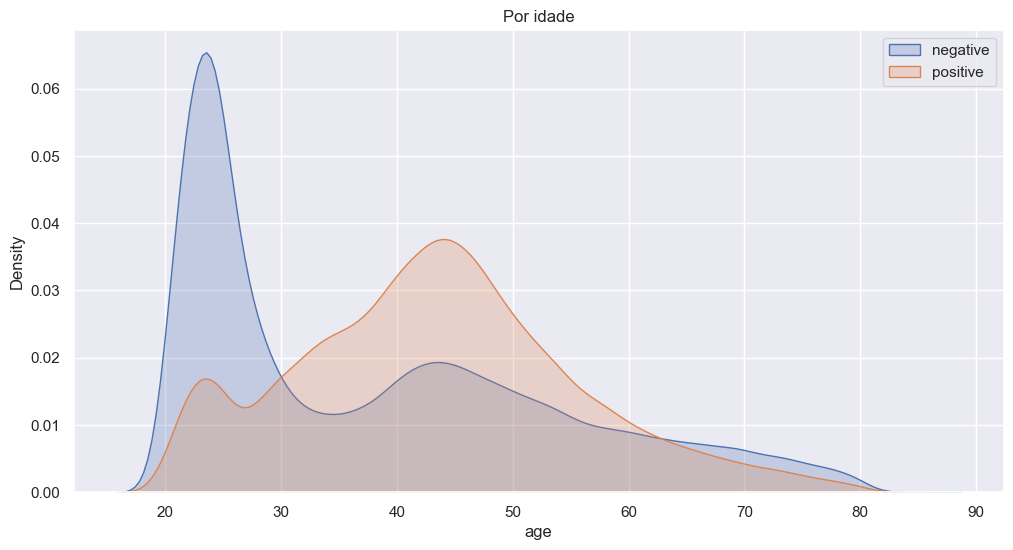

In [155]:
plt.subplot(1,1,1)
filter0 = (df5['response'] == 0)
filter1 = (df5['response'] == 1)

sns.kdeplot( df5.loc[filter0, 'age'], label='negative', fill=True )
sns.kdeplot( df5.loc[filter1, 'age'], label='positive', fill=True )
plt.legend()
plt.title('Por idade')
plt.show();

### 5.3 - H3 - Pessoas com carros mais velhos sao mais propensas a adquirir o seguro saude

Verdadeiro. Quanto mais velho o carro, mais propenso de adquirir o seguro saude.

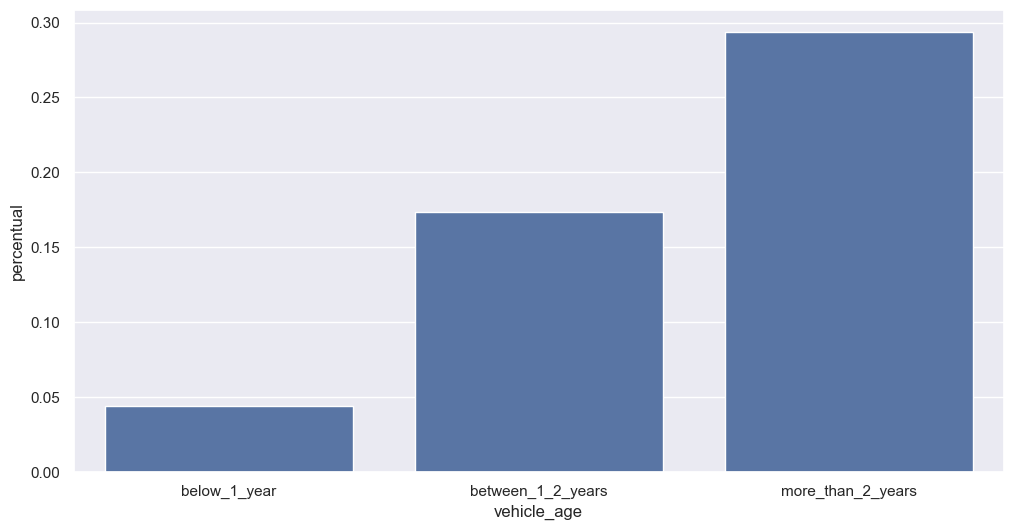

In [156]:
aux = df5.loc[:, ['vehicle_age','response']].groupby(by=['vehicle_age']).agg({'vehicle_age':'count','response':'sum'})
aux.columns = ['total','positive']
aux = aux.reset_index()
aux['percentual'] = aux['positive']/aux['total']

sns.barplot(data=aux, x='vehicle_age', y='percentual')
plt.show();

### 5.4 - H4 - Pessoas com carros danificados sao mais propensas a adquirir o seguro saude

Verdadeiro. Pessoas com carros danificados são mais propensas a adquirir o seguro saúde

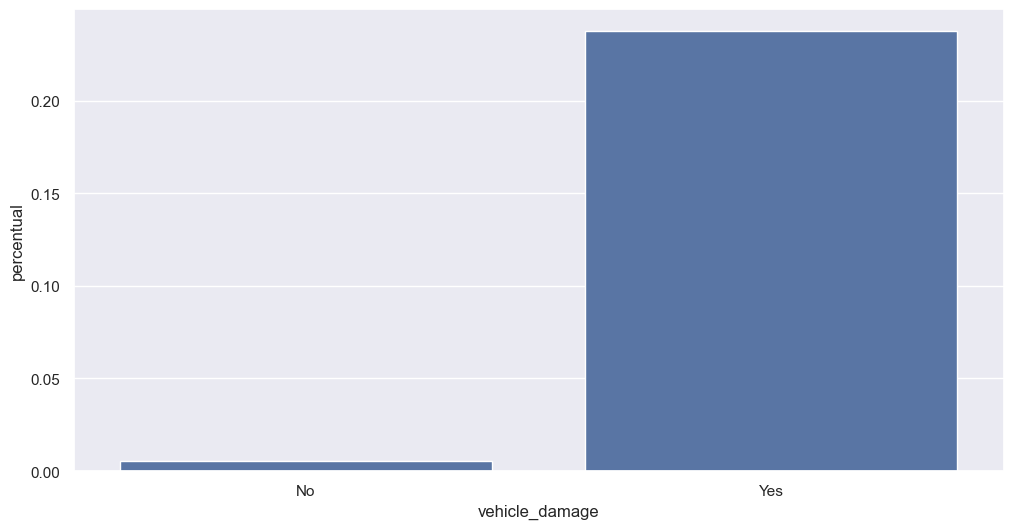

In [157]:
aux = df5.loc[:, ['vehicle_damage','response']].groupby(by=['vehicle_damage']).agg({'vehicle_damage':'count','response':'sum'})
aux.columns = ['total','positive']
aux = aux.reset_index()
aux['percentual'] = aux['positive']/aux['total']

sns.barplot(data=aux, x='vehicle_damage', y='percentual')
plt.show();

### 5.5 - H5 - Pessoas previamente asseguradas sao mais propensas a adquirir o seguro saude

Falso. Pessoas nunca asseguradas são as mais propensas a adquirir o seguro saude

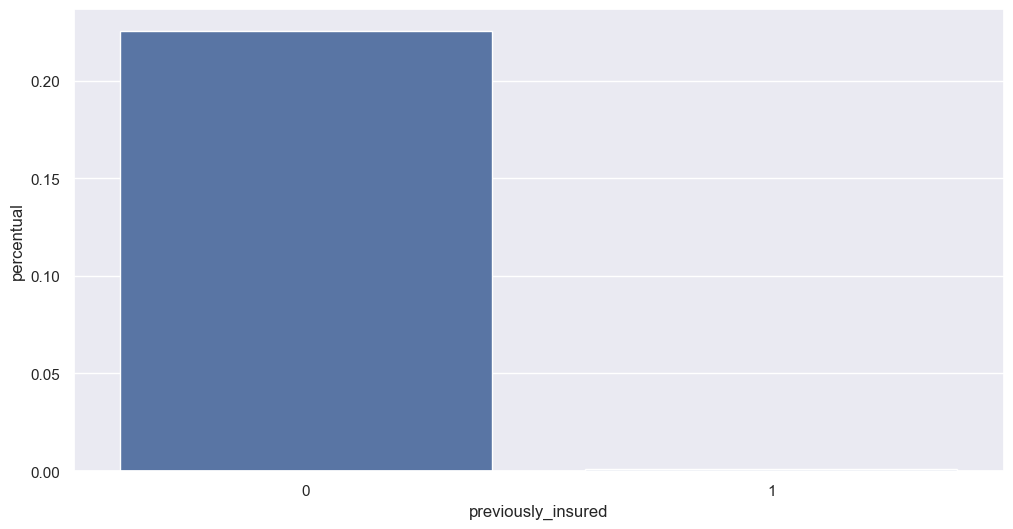

In [158]:
aux = df5.loc[:, ['previously_insured','response']].groupby(by=['previously_insured']).agg({'previously_insured':'count','response':'sum'})
aux.columns = ['total','positive']
aux = aux.reset_index()
aux['percentual'] = aux['positive']/aux['total']

sns.barplot(data=aux, x='previously_insured', y='percentual')
plt.show();

### 5.6 - H6 - Pessoas que ganham mais sao mais propensas a adquirir o seguro saude

Falso. Cancela da mesma maneira

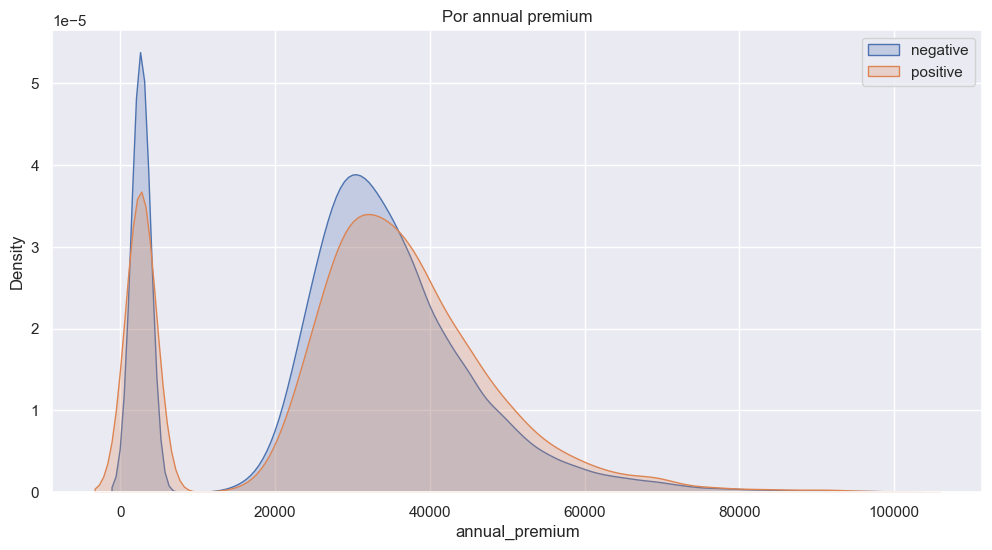

In [159]:
plt.subplot(1,1,1)
filter0 = (df5['response'] == 0) & (df5['annual_premium'] < 100000)
filter1 = (df5['response'] == 1) & (df5['annual_premium'] < 100000)

sns.kdeplot( df5.loc[filter0, 'annual_premium'], label='negative', fill=True )
sns.kdeplot( df5.loc[filter1, 'annual_premium'], label='positive', fill=True )
plt.legend()
plt.title('Por annual premium')
plt.show();

### 5.7 - H7 Pessoas a mais tempo associadas sao mais propensas a adquirir o seguro saude

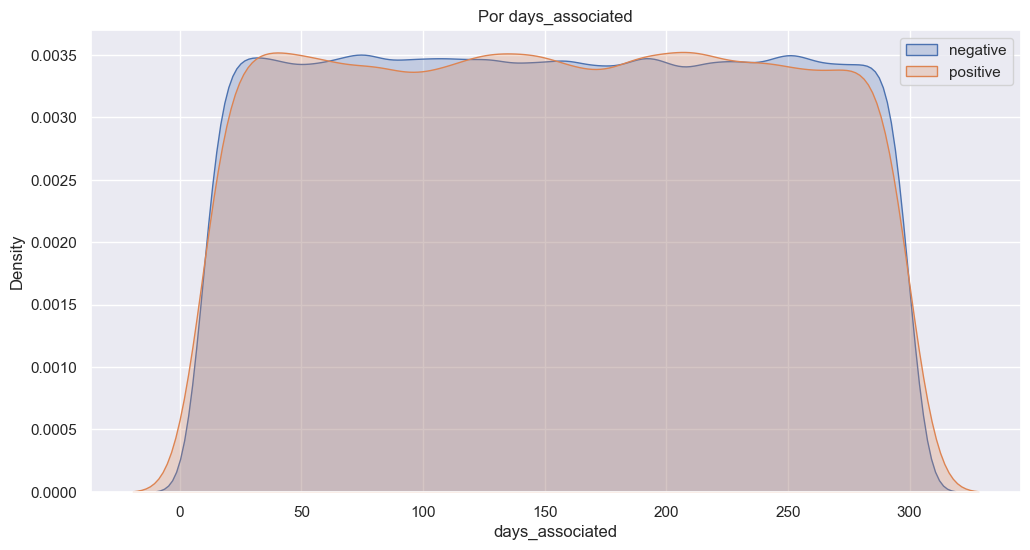

In [160]:
plt.subplot(1,1,1)
filter0 = (df5['response'] == 0)
filter1 = (df5['response'] == 1)

sns.kdeplot( df5.loc[filter0, 'days_associated'], label='negative', fill=True )
sns.kdeplot( df5.loc[filter1, 'days_associated'], label='positive', fill=True )
plt.legend()
plt.title('Por days_associated')
plt.show();

### 5.8 - H8 

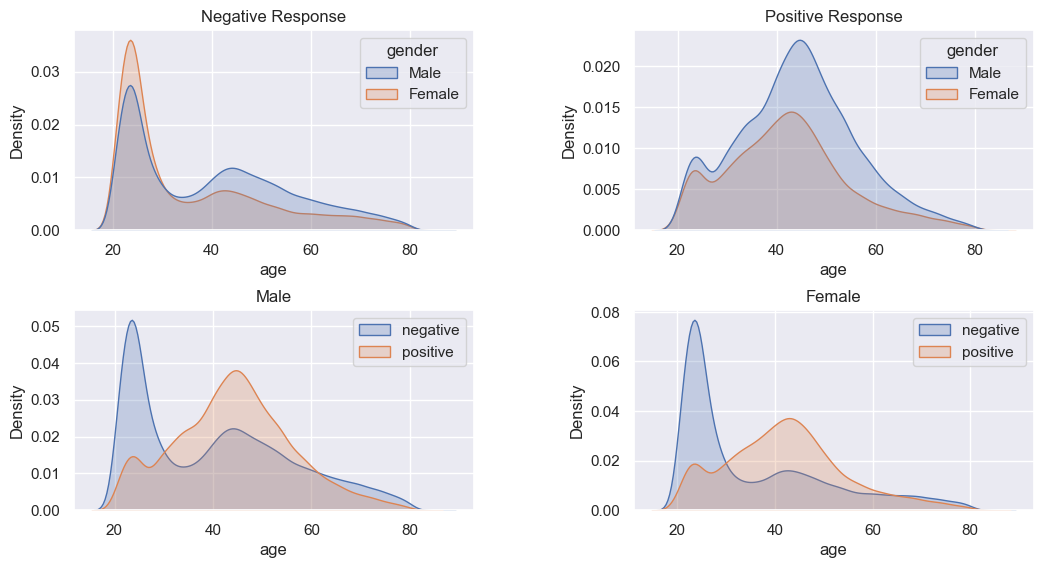

In [161]:
subplots_adjust()

plt.subplot(2,2,1)
sns.kdeplot( data=df5.loc[ df5['response'] == 0, ['gender', 'age']], x='age', hue='gender', fill=True, )
plt.title('Negative Response')

plt.subplot(2,2,2)
sns.kdeplot( data=df5.loc[ df5['response'] == 1, ['gender', 'age']], x='age', hue='gender', fill=True, )
plt.title('Positive Response')

plt.subplot(2,2,3)
filter0 = (df5['gender'] == 'Male') & (df5['response'] == 0)
filter1 = (df5['gender'] == 'Male') & (df5['response'] == 1)

sns.kdeplot( df5.loc[filter0, 'age'], label='negative', fill=True )
sns.kdeplot( df5.loc[filter1, 'age'], label='positive', fill=True )
plt.legend()
plt.title('Male')

plt.subplot(2,2,4)
filter0 = (df5['gender'] == 'Female') & (df5['response'] == 0)
filter1 = (df5['gender'] == 'Female') & (df5['response'] == 1)

sns.kdeplot( df5.loc[filter0, 'age'], label='negative', fill=True )
sns.kdeplot( df5.loc[filter1, 'age'], label='positive', fill=True )
plt.legend()
plt.title('Female')
plt.show();

## 5.3 Análise multivariada

### 5.3.1 Numerical Attributes


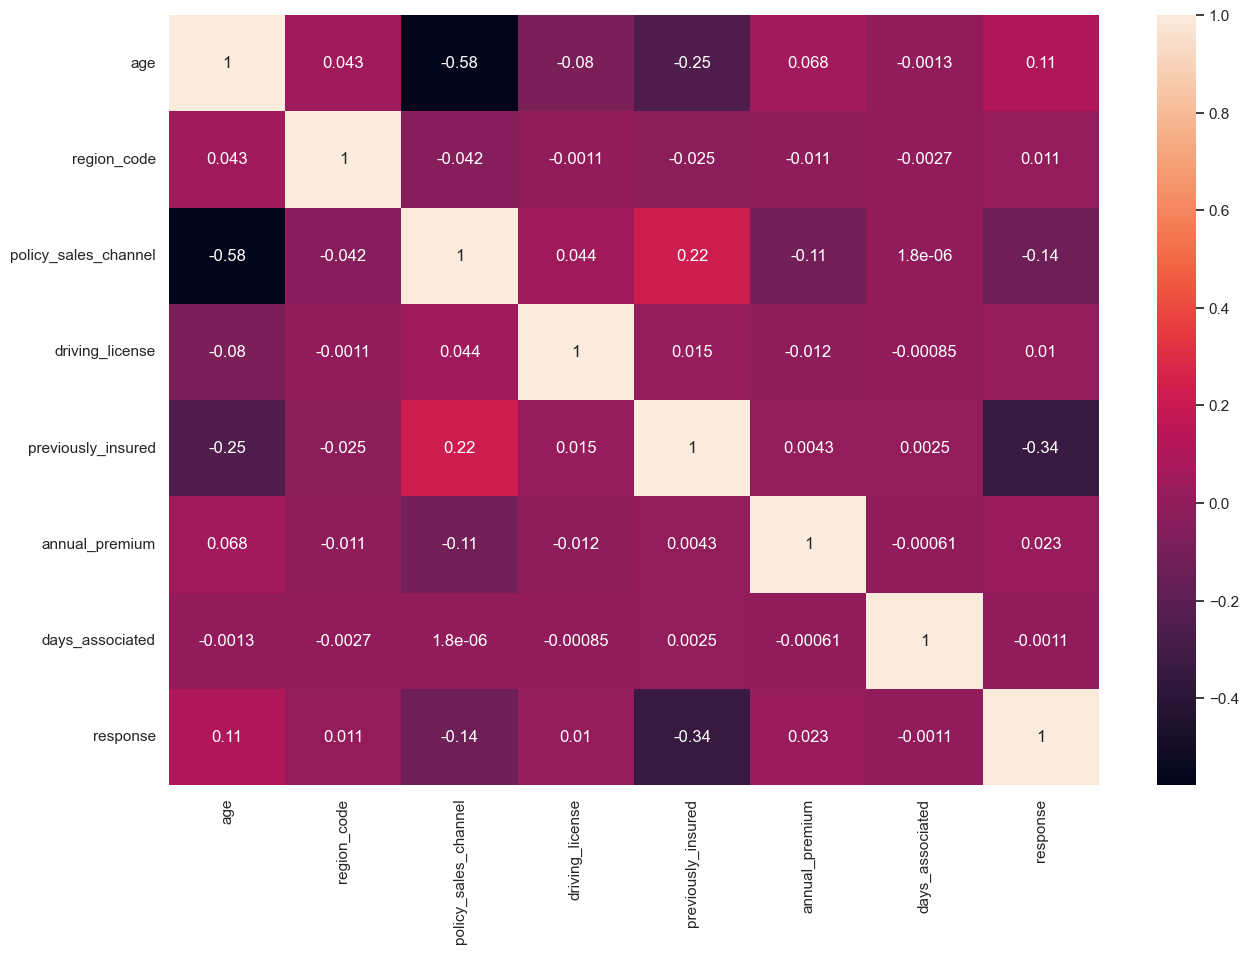

In [162]:
fig, ax = plt.subplots(figsize=(15, 10))

correlation = num_attributes.corr( method='pearson' )
sns.heatmap( correlation, annot=True )
plt.show();

# 6.0 Data Preparation

In [163]:
df6 = df5.copy()

## 6.2 Transformação

In [164]:
df6

,id,gender,age,region_code,policy_sales_channel,driving_license,vehicle_age,vehicle_damage,previously_insured,annual_premium,days_associated,response
0,1,Male,44,28,26,1,more_than_2_years,Yes,0,40454.0,217,1
1,2,Male,76,3,26,1,between_1_2_years,No,0,33536.0,183,0
2,3,Male,47,28,26,1,more_than_2_years,Yes,0,38294.0,27,1
3,4,Male,21,11,152,1,below_1_year,No,1,28619.0,203,0
4,5,Female,29,41,152,1,below_1_year,No,1,27496.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,26,26,1,between_1_2_years,No,1,30170.0,88,0
381105,381106,Male,30,37,152,1,below_1_year,No,1,40016.0,131,0
381106,381107,Male,21,30,160,1,below_1_year,No,1,35118.0,161,0
381107,381108,Female,68,14,124,1,more_than_2_years,Yes,0,44617.0,74,0


In [165]:
# One Hot Encoding
df6['vehicle_damage'] = df6['vehicle_damage'].apply(lambda x: 1 if x=='Yes' else 0)
df6['gender'] = df6['gender'].apply(lambda x: 1 if x=='Male' else 0)

# Target Encoding
vehicle_age_encoding = {'below_1_year':1, 'between_1_2_years':2, 'more_than_2_years':3}
df6['vehicle_age'] = df6['vehicle_age'].map(vehicle_age_encoding)

region_code_encoding = df6.groupby('region_code')['response'].mean()
df6['region_code'] = df6['region_code'].map(region_code_encoding)

policy_sales_channel_encoding = df6.groupby('policy_sales_channel')['response'].mean()
df6['policy_sales_channel'] = df6['policy_sales_channel'].map(policy_sales_channel_encoding)

In [166]:
ss = StandardScaler()

df6['annual_premium']       = ss.fit_transform(df6[['annual_premium']].values)
df6['days_associated']      = ss.fit_transform(df6[['days_associated']].values)
df6['age']                  = ss.fit_transform(df6[['age']].values)
df6['policy_sales_channel'] = ss.fit_transform(df6[['policy_sales_channel']].values)
df6['region_code']          = ss.fit_transform(df6[['region_code']].values)

# 7.0 Feature Selection

In [167]:
df7 = df6.copy()

# 8.0. Machine Learning Model

In [168]:
df8 = df6.copy()

X = df8.drop(columns=['id','response'])
y = df8['response']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## 8.1. Linear Regression

In [169]:
# Log. Regression
lr = LogisticRegression( max_iter=1000 )

# Training the Model
lr.fit(X_train, y_train)

# Predicting
y_predict = lr.predict( X_test )
yhat_proba = lr.predict_proba( X_test )

# Recall at K - Preparação dos dados para plotagem e salvando o valor de recall_at_k
df_class_0, df_class_1, recall_at_k = calculate_data_recall_at_k(y_test, yhat_proba, k=0.4)

# Showing the metrics
accuracy_score,precision_score,recall_score,f1_score = model_metrics(X_test, y_test, yhat_proba, y_predict)

# Aggregating the results in a dataframe
lr_results = {'model':['Regressão Logistica'], 'Acurácia': [accuracy_score], 'Precisão':[precision_score], 'Recall': [recall_score], 'f1_score':[f1_score], 'k': [0.4], 'recall_at_k': [recall_at_k]}
df_lr = pd.DataFrame(lr_results)
df_lr

,model,Acurácia,Precisão,Recall,f1_score,k,recall_at_k
0,Regressão Logistica,0.876078,0.391753,0.00646,0.01271,0.4,0.918487


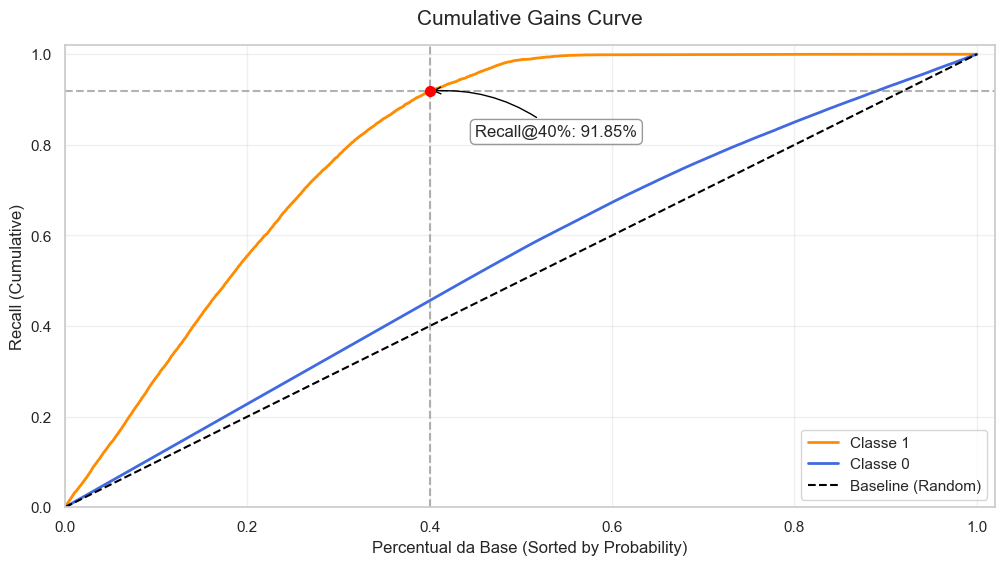

In [170]:
# Plotando a curva cumulativa de ganho para k=40%
lineplot_recall_at_k(df_class_0, df_class_1, recall_at_k, k=0.4)

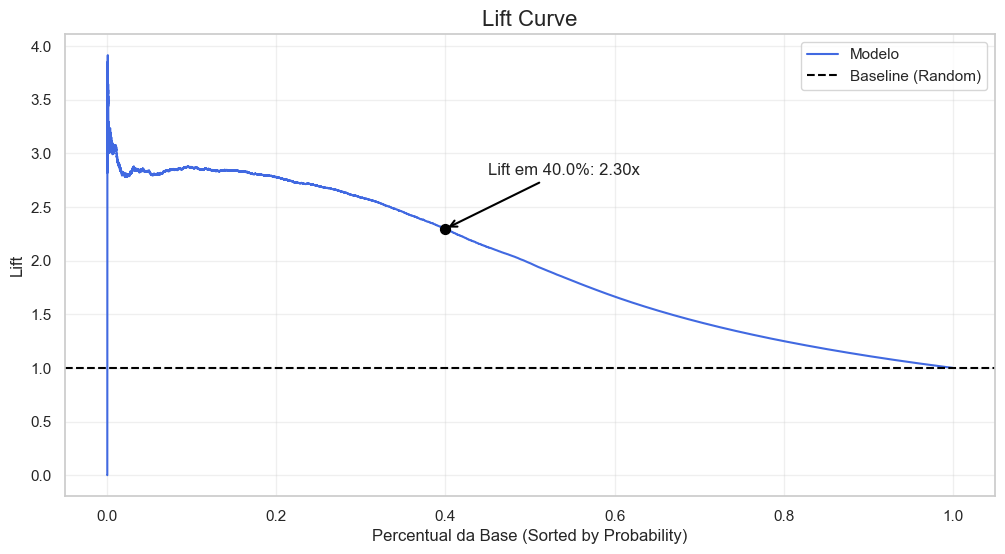

In [171]:
# Gerando DataFrame com calculo da Curva Lift
lift_data = calculate_lift_data(y_test, yhat_proba)

# Plotando Curva Lift
plot_lift_curve(lift_data, k=0.4);

## 8.2. XGBoost Classifier

In [172]:
# XGBoost Classifier Model
xgb_model = xgb.XGBClassifier(colsample_bytree=0.7, learning_rate=0.1, max_depth=10, n_estimators=100)

# Treinando o modelo
xgb_model.fit(X_train, y_train)

# Realizando as previsões
y_predict_xgb = xgb_model.predict( X_test )
yhat_proba_xgb = xgb_model.predict_proba(X_test)

# Recall at K - Preparação dos dados para plotagem e salvando o valor de recall_at_k
df_class_0, df_class_1, recall_at_k = calculate_data_recall_at_k(y_test, yhat_proba_xgb, k=0.4)

# Showing the metrics
accuracy_score,precision_score,recall_score,f1_score = model_metrics(X_test, y_test, yhat_proba_xgb, y_predict_xgb)

# Registrando os resultados em um dataframe
xgb_results = {'model':['XGBoost Classifier'], 'Acurácia': [accuracy_score], 'Precisão':[precision_score], 'Recall': [recall_score], 'f1_score':[f1_score], 'k': [0.4], 'recall_at_k': [recall_at_k]}
df_xgb = pd.DataFrame(xgb_results)
df_xgb

,model,Acurácia,Precisão,Recall,f1_score,k,recall_at_k
0,XGBoost Classifier,0.876236,0.47448,0.021334,0.040833,0.4,0.927412


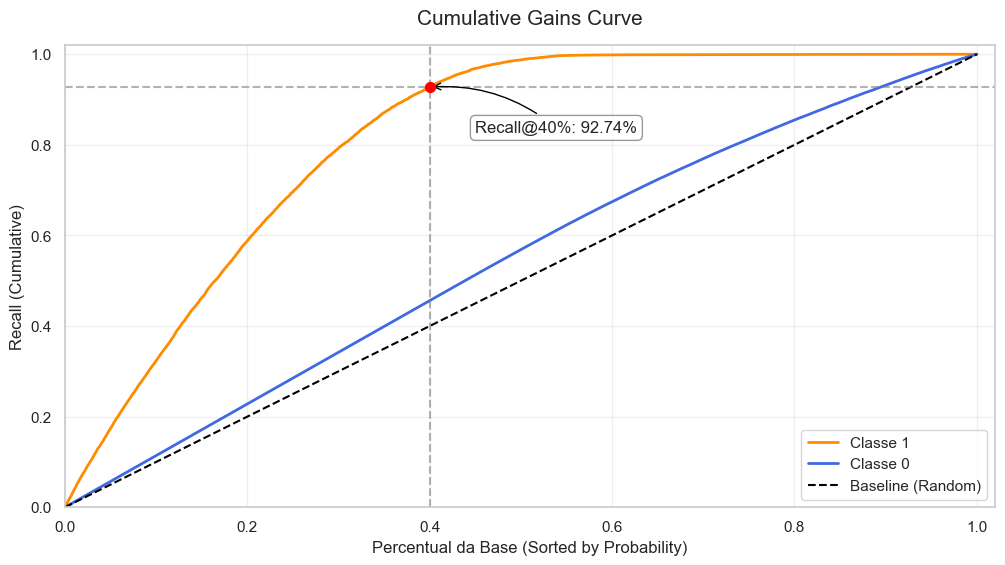

In [173]:
# Plotando a curva cumulativa de ganho para k=40%
lineplot_recall_at_k(df_class_0, df_class_1, recall_at_k, k=0.4)

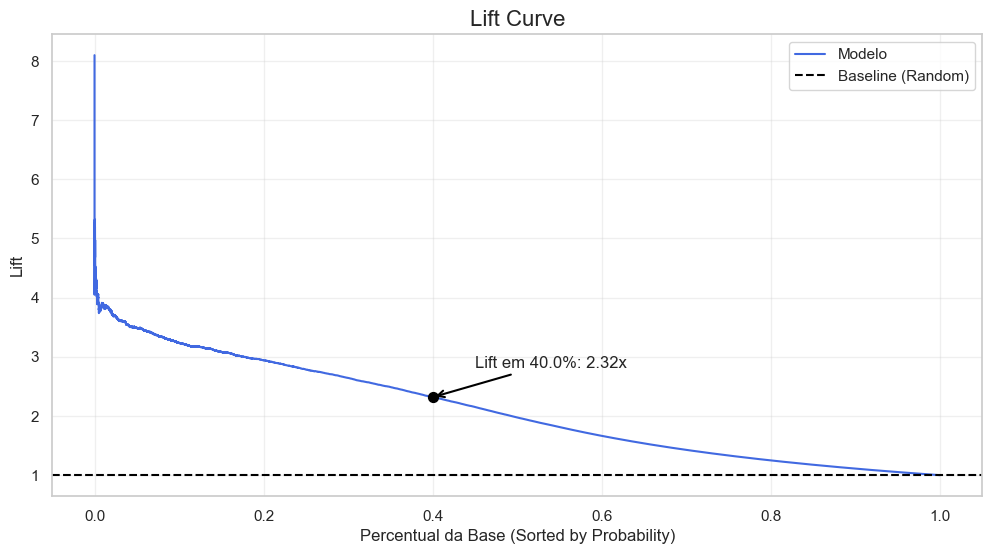

In [174]:
# Gerando DataFrame com calculo da Curva Lift
lift_data = calculate_lift_data(y_test, yhat_proba_xgb)

# Plotando Curva Lift
plot_lift_curve(lift_data, k=0.4);

## 8.3. Gradient Boosting Classifier

In [175]:
# Gradient Boost Classifier Model
gbrt = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_features=3, max_depth=5, random_state=42)

# Treinando o modelo
gbrt.fit(X_train, y_train)

# Realizando as previsões
y_predict_gbc  = gbrt.predict(X_test)
yhat_proba_gbc = gbrt.predict_proba(X_test)

# Recall at K - Preparação dos dados para plotagem e salvando o valor de recall_at_k
df_class_0, df_class_1, recall_at_k = calculate_data_recall_at_k(y_test, yhat_proba_gbc, k=0.4)

# Showing the metrics
accuracy_score,precision_score,recall_score,f1_score = model_metrics(X_test, y_test, yhat_proba_gbc, y_predict_gbc)

# Registrando os resultados em um dataframe
gbrt_results = {'model':['Gradient Boosting Classifier'], 'Acurácia': [accuracy_score], 'Precisão':[precision_score], 'Recall': [recall_score], 'f1_score':[f1_score], 'k': [0.4], 'recall_at_k': [recall_at_k]}
df_gbrt = pd.DataFrame(gbrt_results)
df_gbrt

,model,Acurácia,Precisão,Recall,f1_score,k,recall_at_k
0,Gradient Boosting Classifier,0.876645,0.596774,0.003145,0.006257,0.4,0.930472


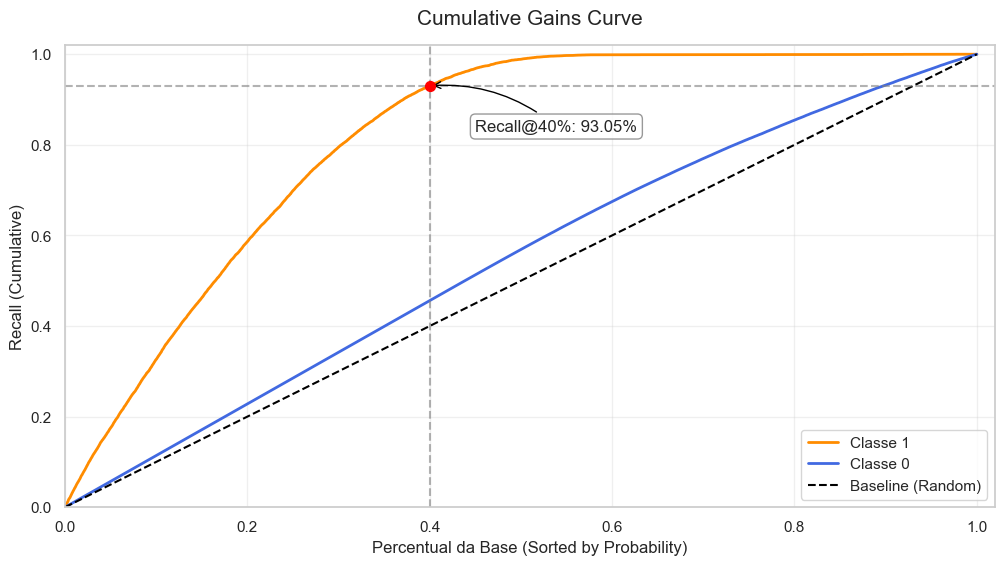

In [176]:
# Plotando a curva cumulativa de ganho para k=40%
lineplot_recall_at_k(df_class_0, df_class_1, recall_at_k, k=0.4)

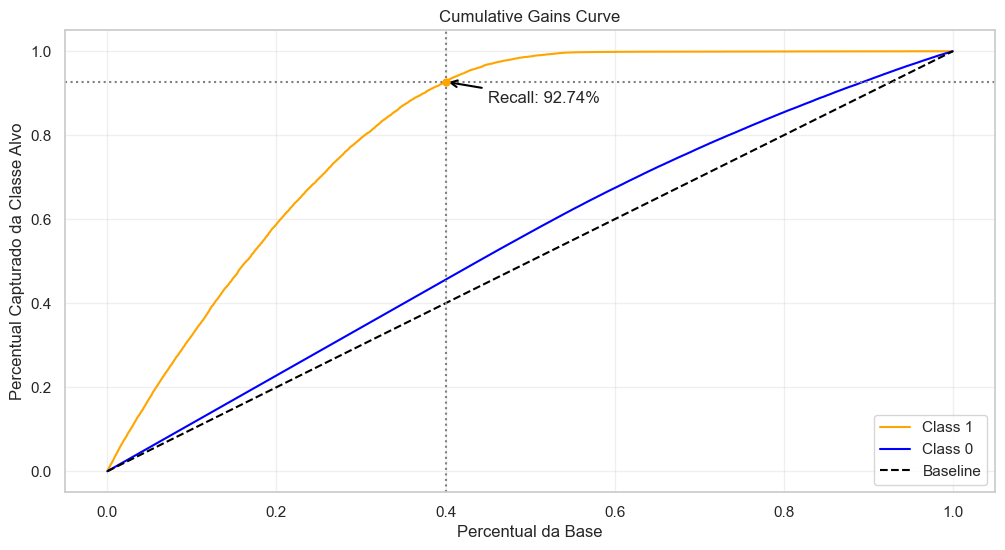

In [177]:
# Plotando a curva cumulativa de ganho para k=40%
plot_graph_recall_at_k(aux_prob_0, aux_prob_1)

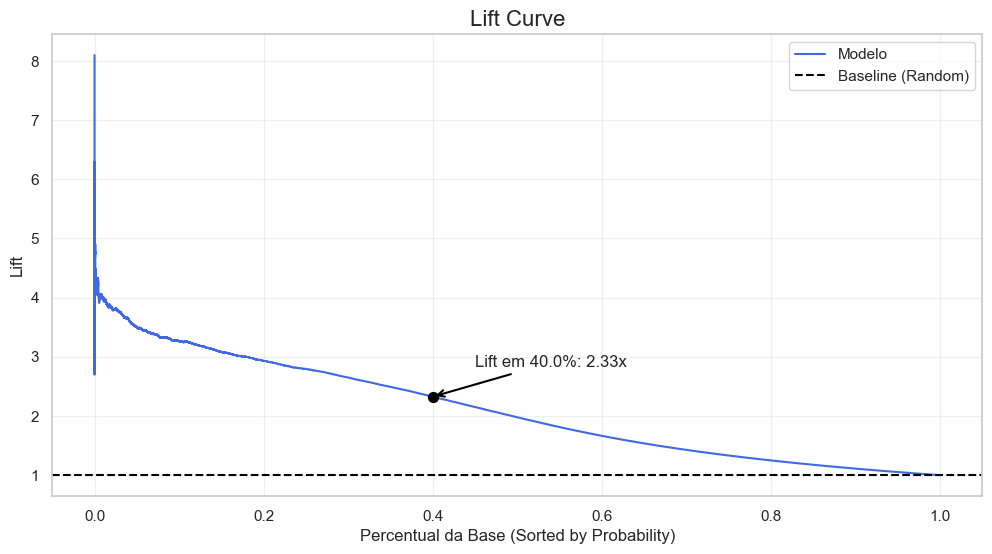

In [178]:
# Gerando DataFrame com calculo da Curva Lift
lift_data = calculate_lift_data(y_test, yhat_proba_gbc)

# Plotando Curva Lift
plot_lift_curve(lift_data, k=0.4);

## 8.4. KNN

In [179]:
# K-Nearest Neighbors Model
knn = KNeighborsClassifier(n_neighbors=75)

# Treinando o modelo
knn.fit(X_train, y_train)

# Realizando as previsões
y_predict_knn  = knn.predict(X_test)
yhat_proba_knn = knn.predict_proba(X_test)

# Recall at K - Preparação dos dados para plotagem e salvando o valor de recall_at_k 
df_class_0, df_class_1, recall_at_k = calculate_data_recall_at_k(y_test, yhat_proba_knn, k=0.4)

# Showing the metrics
accuracy_score,precision_score,recall_score,f1_score = model_metrics(X_test, y_test, yhat_proba_knn, y_predict_knn)

# Registrando os resultados em um dataframe
knn_results = {'model':['K-Nearest Neighbors'], 'Acurácia': [accuracy_score], 'Precisão':[precision_score], 'Recall': [recall_score], 'f1_score':[f1_score], 'k': [0.4], 'recall_at_k': [recall_at_k]}
df_knn = pd.DataFrame(knn_results)
df_knn

,model,Acurácia,Precisão,Recall,f1_score,k,recall_at_k
0,K-Nearest Neighbors,0.876267,0.454887,0.010285,0.020115,0.4,0.917722


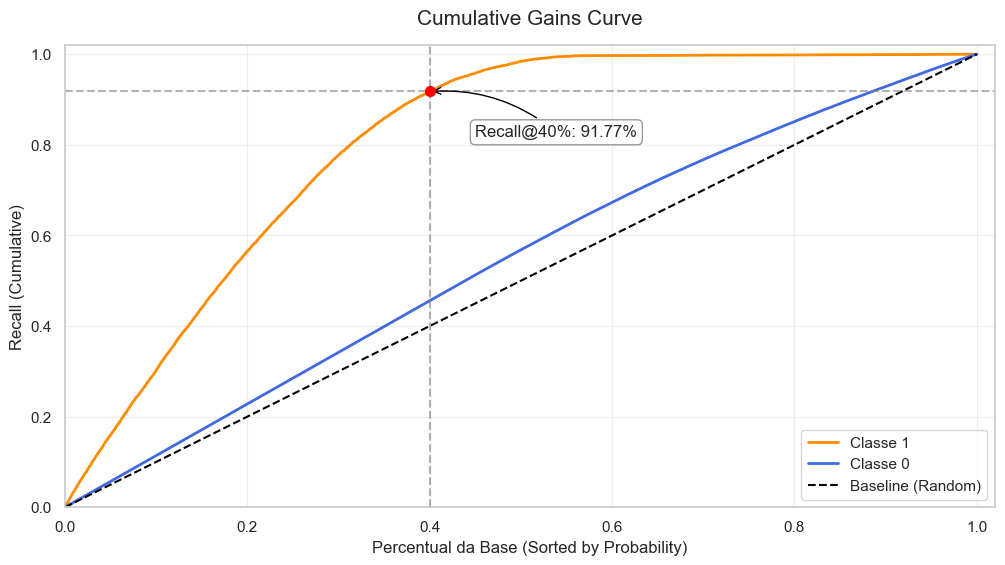

In [180]:
# Plotando a curva cumulativa de ganho para k=40%
lineplot_recall_at_k(df_class_0, df_class_1, recall_at_k, k=0.4)

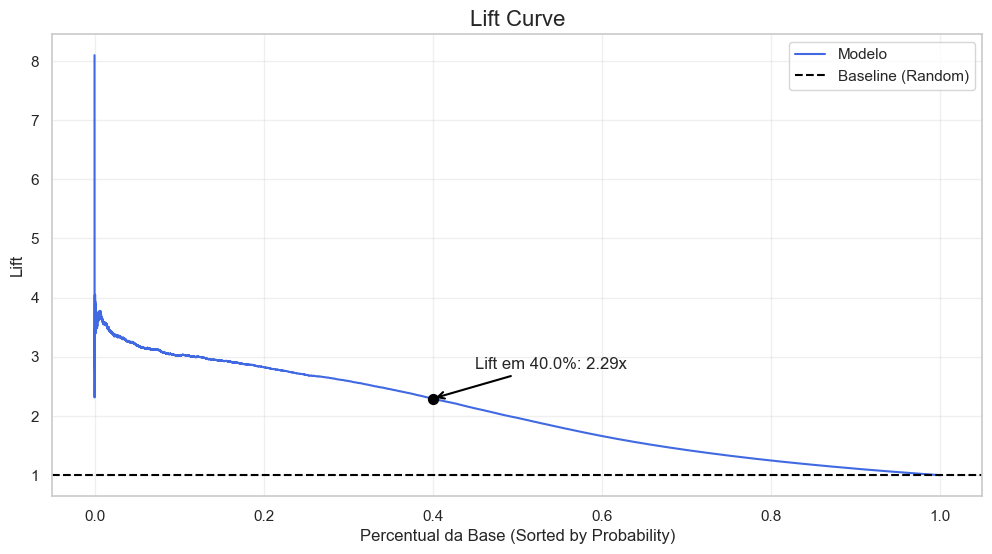

In [181]:
# Gerando DataFrame com calculo da Curva Lift
lift_data = calculate_lift_data(y_test, yhat_proba_knn)

# Plotando Curva Lift
plot_lift_curve(lift_data, k=0.4);

## 8.5. Comparing Models

Modelo vencedor: Gradient Boosting Classifier

In [182]:
# Concatenando o resultado de todos modelos testados
models_results = pd.concat([df_lr, df_xgb,df_gbrt,df_knn], axis=0)

# Show Results
models_results.sort_values(by='recall_at_k', ascending=False).reset_index(drop=True)

,model,Acurácia,Precisão,Recall,f1_score,k,recall_at_k
0,Gradient Boosting Classifier,0.876645,0.596774,0.003145,0.006257,0.4,0.930472
1,XGBoost Classifier,0.876236,0.474480,0.021334,0.040833,0.4,0.927412
2,Regressão Logistica,0.876078,0.391753,0.006460,0.012710,0.4,0.918487
3,K-Nearest Neighbors,0.876267,0.454887,0.010285,0.020115,0.4,0.917722
